# Week 6 Video Notebook: Decision Trees

In this notebook, we will learn how to build, analyze, tune, and evaluate decision tree models using scikit-learn.

In earlier weeks, we used separate training, validation, and test sets to develop a model. This week, we replace the single validation set with **cross-validation**. For each dataset, we will first set aside an untouched test set. We will then use cross-validation within the remaining development data to study hyperparameters and compare candidate models.

We will work through:

- a regression example using the **Auto MPG dataset**;
- a classification example using the **Default of Credit Card Clients dataset**.

These datasets were used in Week 4 and Week 5, respectively.

Along the way, we will:

* build decision tree models for **regression** and **classification**;
* use **MAE** to evaluate regression models and **ROC AUC** to evaluate classification models;
* use **cross-validation** and validation curves to study underfitting, overfitting, and important decision-tree hyperparameters;
* compare promising tree configurations using **repeated cross-validation**;
* select the final models using the development data and evaluate them once on the untouched test set;
* examine decision-tree feature importance;
* compare the regression tree with linear and quadratic regression, and the classification tree with logistic regression.

**Remember:** the test set is reserved for final evaluation and does not participate in model selection.


In [1]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    r2_score,    
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler
)
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor
)


# --------------------------------------------------
# Global Settings
# --------------------------------------------------

random_seed = 42

## Decision Tree Regression

### Load and Prepare the Auto MPG Dataset

We will return to the Auto MPG dataset from Week 4. Because we are already familiar with the variables and prediction task, we can focus on how decision tree regression differs from linear and polynomial regression.

The target is `mpg`, or miles per gallon. We will remove the automobile name because it is an identifier rather than a useful general predictor. The `origin` feature will be treated as categorical, and missing values in `horsepower` will be handled within the modeling pipeline.

In [2]:
# --------------------------------------------------
# Load the Auto MPG Dataset
# --------------------------------------------------

mpg_data = sns.load_dataset("mpg")

display(mpg_data.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
mpg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


### Prepare the Predictors and Create the Development/Test Split

We first separate the target from the predictors and remove the automobile name. We then create a development set for model selection and an untouched test set for final evaluation.

All preprocessing steps will be placed inside the modeling pipeline so that they are learned separately within each cross-validation training fold.

In [4]:
# --------------------------------------------------
# Prepare the Predictors and Target
# --------------------------------------------------

# Separate predictors and target
X_mpg = mpg_data.drop(
    columns=[
        "mpg",
        "name"
    ]
)

y_mpg = mpg_data["mpg"]

# Treat origin as a categorical predictor
X_mpg["origin"] = X_mpg["origin"].astype("category")


# --------------------------------------------------
# Identify Predictor Types
# --------------------------------------------------

quantitative_features = X_mpg.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = X_mpg.select_dtypes(
    exclude="number"
).columns.tolist()

print("Quantitative features:")
print(quantitative_features)

print("\nCategorical features:")
print(categorical_features)


# --------------------------------------------------
# Development / Test Split
# --------------------------------------------------

X_mpg_development, X_mpg_test, y_mpg_development, y_mpg_test = train_test_split(
    X_mpg,
    y_mpg,
    test_size=0.10,
    random_state=random_seed
)

print("\nDevelopment set:")
print(X_mpg_development.shape, y_mpg_development.shape)

print("\nTest set:")
print(X_mpg_test.shape, y_mpg_test.shape)

Quantitative features:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

Categorical features:
['origin']

Development set:
(358, 7) (358,)

Test set:
(40, 7) (40,)


### Baseline Decision Tree Regressor

We begin with a decision tree regressor using its default hyperparameter values. The model will be evaluated using shuffled 5-fold cross-validation on the development set, with mean absolute error as the scoring metric.

The pipeline will also perform the required imputation and categorical encoding within each cross-validation fold.

In [5]:
# --------------------------------------------------
# Baseline Decision Tree Regression Pipeline
# --------------------------------------------------

# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

# Impute missing quantitative values
quantitative_pipeline = make_pipeline(
    SimpleImputer(strategy="median")
)

# Impute and encode categorical values
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(
        handle_unknown="ignore"
    )
)

# Apply the appropriate preprocessing to each
# group of predictors
preprocessor = make_column_transformer(
    (
        quantitative_pipeline,
        quantitative_features
    ),
    (
        categorical_pipeline,
        categorical_features
    )
)


# --------------------------------------------------
# Baseline Modeling Pipeline
# --------------------------------------------------

# All preprocessing is fitted separately within each
# cross-validation training fold
decision_tree_pipeline = make_pipeline(

    preprocessor,

    DecisionTreeRegressor(

        # Splitting criterion
        criterion="squared_error",

        # Tree size
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_leaf_nodes=None,

        # Feature selection
        max_features=None,

        # Cost-complexity pruning
        ccp_alpha=0.0,

        # Reproducibility
        random_state=random_seed
    )
)


# --------------------------------------------------
# Five-Fold Cross-Validation
# --------------------------------------------------

regression_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)

neg_mae_scores = cross_val_score(
    decision_tree_pipeline,
    X_mpg_development,
    y_mpg_development,
    scoring="neg_mean_absolute_error",
    cv=regression_cv,
    n_jobs=-1
)

# Convert scikit-learn's negative MAE scores
# back to positive MAE values
cv_mae_scores = -neg_mae_scores

mean_cv_mae = cv_mae_scores.mean()
std_cv_mae = cv_mae_scores.std()


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Baseline Decision Tree Regression")
print("---------------------------------")
print(f"5-Fold MAEs : {np.round(cv_mae_scores, 4)}")
print(f"Mean CV MAE : {mean_cv_mae:.4f}")
print(f"Std CV MAE  : {std_cv_mae:.4f}")

Baseline Decision Tree Regression
---------------------------------
5-Fold MAEs : [2.1778 2.2556 2.4972 3.0042 2.5521]
Mean CV MAE : 2.4974
Std CV MAE  : 0.2900


### Hyperparameter Tuning: `max_depth`

The `max_depth` hyperparameter limits the number of levels in a decision tree and therefore controls model complexity.

- A small value may produce an overly simple tree that underfits the data.
- A large value may allow the tree to fit the development data very closely while generalizing less effectively to unseen observations.

We will evaluate values of `max_depth` from 2 through 20. For each value, we will use the same shuffled 5-fold cross-validation procedure to calculate the mean training MAE and mean validation MAE.

All preprocessing remains inside the pipeline and is fitted separately within each cross-validation training fold. The other decision-tree hyperparameters remain at their default values.

The preferred value of `max_depth` is the one with the lowest mean cross-validation MAE.

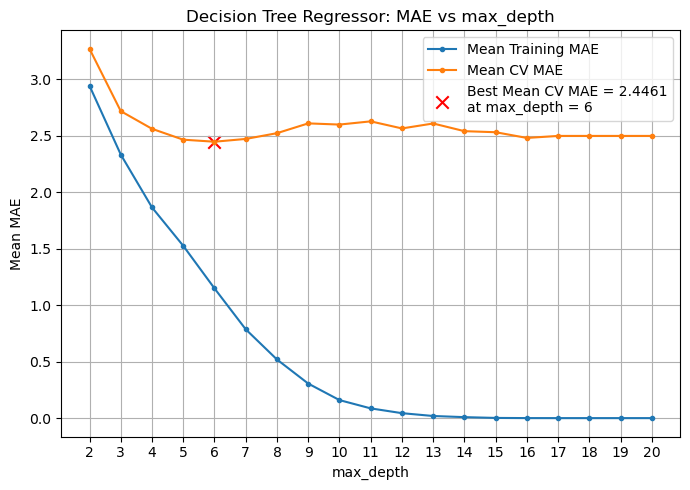

max_depth Tuning Results
------------------------
Best max_depth : 6
Mean CV MAE    : 2.4461
Std CV MAE     : 0.3375


In [6]:
# --------------------------------------------------
# Validation Curve for max_depth
# --------------------------------------------------

training_maes = []
cv_maes = []

training_mae_stds = []
cv_mae_stds = []

max_depth_values = range(2, 21)

for max_depth in max_depth_values:

    # Construct the full preprocessing + modeling pipeline
    max_depth_pipeline = make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            max_depth=max_depth,
            min_samples_split=2,
            min_samples_leaf=1,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=0.0,
            random_state=random_seed
        )
    )

    # Evaluate training and validation performance
    # within each cross-validation fold
    scores = cross_validate(
        max_depth_pipeline,
        X_mpg_development,
        y_mpg_development,
        scoring="neg_mean_absolute_error",
        cv=regression_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Convert negative MAE scores to positive values
    fold_training_maes = -scores["train_score"]
    fold_cv_maes = -scores["test_score"]

    # Store means
    training_maes.append(
        fold_training_maes.mean()
    )

    cv_maes.append(
        fold_cv_maes.mean()
    )

    # Store standard deviations
    training_mae_stds.append(
        fold_training_maes.std()
    )

    cv_mae_stds.append(
        fold_cv_maes.std()
    )


# --------------------------------------------------
# Identify the Best max_depth
# --------------------------------------------------

best_index = np.argmin(cv_maes)

best_max_depth = list(max_depth_values)[best_index]
best_max_depth_cv_mae = cv_maes[best_index]
best_max_depth_cv_mae_std = cv_mae_stds[best_index]


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    max_depth_values,
    training_maes,
    marker=".",
    label="Mean Training MAE"
)

plt.plot(
    max_depth_values,
    cv_maes,
    marker=".",
    label="Mean CV MAE"
)

plt.scatter(
    best_max_depth,
    best_max_depth_cv_mae,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV MAE = "
        f"{best_max_depth_cv_mae:.4f}\n"
        f"at max_depth = {best_max_depth}"
    )
)

plt.title(
    "Decision Tree Regressor: MAE vs max_depth"
)
plt.xlabel("max_depth")
plt.ylabel("Mean MAE")
plt.xticks(list(max_depth_values))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("max_depth Tuning Results")
print("------------------------")
print(
    f"Best max_depth : {best_max_depth}"
)
print(
    f"Mean CV MAE    : "
    f"{best_max_depth_cv_mae:.4f}"
)
print(
    f"Std CV MAE     : "
    f"{best_max_depth_cv_mae_std:.4f}"
)

### Hyperparameter Tuning: `ccp_alpha`

The `ccp_alpha` hyperparameter controls **cost-complexity pruning**. Pruning removes branches that provide too little improvement relative to the additional complexity they introduce.

* When `ccp_alpha = 0`, no cost-complexity pruning is applied, and the tree may grow very large.
* As `ccp_alpha` increases, more branches are removed and the tree becomes simpler.
* A value that is too small may allow the tree to **overfit**.
* A value that is too large may prune away useful structure and cause **underfitting**.

We will vary `ccp_alpha` while leaving the other hyperparameters at their default values. For each value, we will calculate the mean training MAE and mean validation MAE across the same five cross-validation folds. The preferred value is the one with the lowest mean cross-validation MAE.

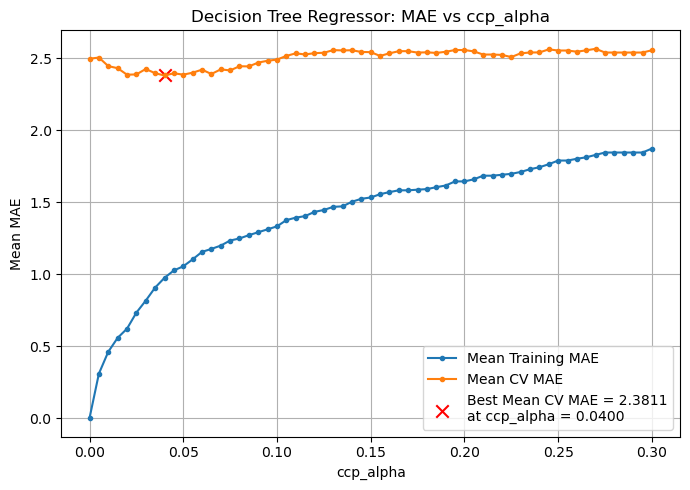

ccp_alpha Tuning Results
------------------------
Best ccp_alpha : 0.0400
Mean CV MAE    : 2.3811
Std CV MAE     : 0.2553


In [7]:
# --------------------------------------------------
# Validation Curve for ccp_alpha
# --------------------------------------------------

training_maes = []
cv_maes = []

training_mae_stds = []
cv_mae_stds = []

ccp_alpha_values = np.linspace(
    0.0,
    0.30,
    61
)

for ccp_alpha in ccp_alpha_values:

    # Construct the full preprocessing + modeling pipeline
    ccp_alpha_pipeline = make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=ccp_alpha,
            random_state=random_seed
        )
    )

    # Evaluate training and validation performance
    # within each cross-validation fold
    scores = cross_validate(
        ccp_alpha_pipeline,
        X_mpg_development,
        y_mpg_development,
        scoring="neg_mean_absolute_error",
        cv=regression_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Convert negative MAE scores to positive values
    fold_training_maes = -scores["train_score"]
    fold_cv_maes = -scores["test_score"]

    # Store means
    training_maes.append(
        fold_training_maes.mean()
    )

    cv_maes.append(
        fold_cv_maes.mean()
    )

    # Store standard deviations
    training_mae_stds.append(
        fold_training_maes.std()
    )

    cv_mae_stds.append(
        fold_cv_maes.std()
    )


# --------------------------------------------------
# Identify the Best ccp_alpha
# --------------------------------------------------

best_index = np.argmin(cv_maes)

best_ccp_alpha = ccp_alpha_values[best_index]
best_ccp_alpha_cv_mae = cv_maes[best_index]
best_ccp_alpha_cv_mae_std = cv_mae_stds[best_index]


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    ccp_alpha_values,
    training_maes,
    marker=".",
    label="Mean Training MAE"
)

plt.plot(
    ccp_alpha_values,
    cv_maes,
    marker=".",
    label="Mean CV MAE"
)

plt.scatter(
    best_ccp_alpha,
    best_ccp_alpha_cv_mae,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV MAE = "
        f"{best_ccp_alpha_cv_mae:.4f}\n"
        f"at ccp_alpha = "
        f"{best_ccp_alpha:.4f}"
    )
)

plt.title(
    "Decision Tree Regressor: MAE vs ccp_alpha"
)
plt.xlabel("ccp_alpha")
plt.ylabel("Mean MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("ccp_alpha Tuning Results")
print("------------------------")
print(
    f"Best ccp_alpha : "
    f"{best_ccp_alpha:.4f}"
)
print(
    f"Mean CV MAE    : "
    f"{best_ccp_alpha_cv_mae:.4f}"
)
print(
    f"Std CV MAE     : "
    f"{best_ccp_alpha_cv_mae_std:.4f}"
)

### Hyperparameter Tuning: `min_samples_leaf`

The `min_samples_leaf` hyperparameter specifies the minimum number of observations that must remain in each terminal leaf.

- A small value allows the tree to create highly specific leaves, which may fit noise in the development data.
- A larger value produces broader, more stable leaves and can reduce overfitting.
- A value that is too large may prevent the tree from capturing meaningful structure and cause underfitting.

We will vary `min_samples_leaf` while leaving the other hyperparameters at their default values. For each value, we will calculate the mean training MAE and mean validation MAE across the same five cross-validation folds.

The preferred value is the one with the lowest mean cross-validation MAE.

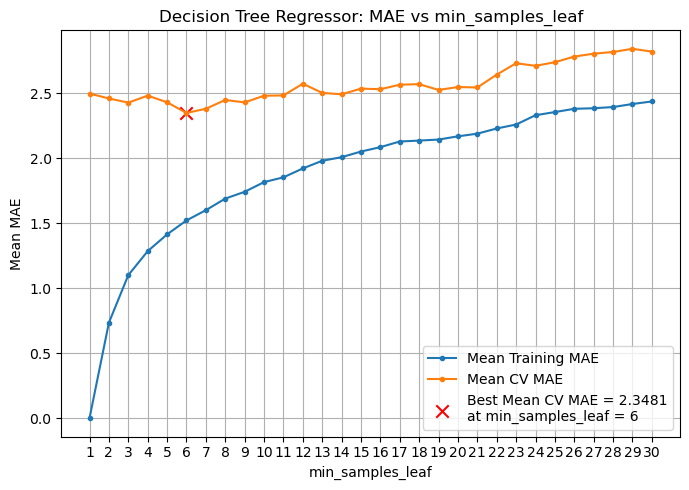

min_samples_leaf Tuning Results
--------------------------------
Best min_samples_leaf : 6
Mean CV MAE           : 2.3481
Std CV MAE            : 0.3275


In [8]:
# --------------------------------------------------
# Validation Curve for min_samples_leaf
# --------------------------------------------------

training_maes = []
cv_maes = []

training_mae_stds = []
cv_mae_stds = []

min_samples_leaf_values = range(1,31)

for min_samples_leaf in min_samples_leaf_values:

    # Construct the full preprocessing + modeling pipeline
    min_samples_leaf_pipeline = make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=min_samples_leaf,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=0.0,
            random_state=random_seed
        )
    )

    # Evaluate training and validation performance
    # within each cross-validation fold
    scores = cross_validate(
        min_samples_leaf_pipeline,
        X_mpg_development,
        y_mpg_development,
        scoring="neg_mean_absolute_error",
        cv=regression_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Convert negative MAE scores to positive values
    fold_training_maes = -scores["train_score"]
    fold_cv_maes = -scores["test_score"]

    # Store means
    training_maes.append(
        fold_training_maes.mean()
    )

    cv_maes.append(
        fold_cv_maes.mean()
    )

    # Store standard deviations
    training_mae_stds.append(
        fold_training_maes.std()
    )

    cv_mae_stds.append(
        fold_cv_maes.std()
    )


# --------------------------------------------------
# Identify the Best min_samples_leaf
# --------------------------------------------------

best_index = np.argmin(cv_maes)

best_min_samples_leaf = list(
    min_samples_leaf_values
)[best_index]

best_min_samples_leaf_cv_mae = cv_maes[best_index]
best_min_samples_leaf_cv_mae_std = cv_mae_stds[best_index]


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    min_samples_leaf_values,
    training_maes,
    marker=".",
    label="Mean Training MAE"
)

plt.plot(
    min_samples_leaf_values,
    cv_maes,
    marker=".",
    label="Mean CV MAE"
)

plt.scatter(
    best_min_samples_leaf,
    best_min_samples_leaf_cv_mae,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV MAE = "
        f"{best_min_samples_leaf_cv_mae:.4f}\n"
        f"at min_samples_leaf = "
        f"{best_min_samples_leaf}"
    )
)

plt.title(
    "Decision Tree Regressor: MAE vs min_samples_leaf"
)
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean MAE")
plt.xticks(min_samples_leaf_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("min_samples_leaf Tuning Results")
print("--------------------------------")
print(
    f"Best min_samples_leaf : "
    f"{best_min_samples_leaf}"
)
print(
    f"Mean CV MAE           : "
    f"{best_min_samples_leaf_cv_mae:.4f}"
)
print(
    f"Std CV MAE            : "
    f"{best_min_samples_leaf_cv_mae_std:.4f}"
)



### Comparing Candidate Decision Trees

The validation curves identified promising values for `max_depth`, `ccp_alpha`, and `min_samples_leaf`. However, each hyperparameter was tuned independently while the others remained at their default values.

We therefore cannot assume that combining the three selected values will necessarily produce the best tree. The hyperparameters may overlap or interact. For example, pruning with `ccp_alpha` may remove branches that would otherwise have been prevented by limiting `max_depth`.

We will construct several candidate trees and compare them using **repeated 5-fold cross-validation with 5 repeats**:

- the default decision tree;
- the selected depth-limited tree;
- the selected pruned tree;
- the selected tree based on minimum leaf size;
- a tree combining all three selected values.

Repeated cross-validation provides a more stable comparison by evaluating each candidate across several different arrangements of the folds. It is used here to compare the candidate models more reliably; the hyperparameter values themselves are not retuned during this step.

The final model will be selected using these development-set results only.

In [9]:
# --------------------------------------------------
# Compare Candidate Models with Repeated CV
# --------------------------------------------------

# Repeated 5-fold cross-validation
repeated_regression_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)


# --------------------------------------------------
# Candidate Modeling Pipelines
# --------------------------------------------------

candidate_models = {

    "Default Tree": make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            random_state=random_seed
        )
    ),

    "Best max_depth": make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            max_depth=best_max_depth,
            random_state=random_seed
        )
    ),

    "Best ccp_alpha": make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            ccp_alpha=best_ccp_alpha,
            random_state=random_seed
        )
    ),

    "Best min_samples_leaf": make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            min_samples_leaf=best_min_samples_leaf,
            random_state=random_seed
        )
    ),

    "Combined Tree": make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            criterion="squared_error",
            max_depth=best_max_depth,
            ccp_alpha=best_ccp_alpha,
            min_samples_leaf=best_min_samples_leaf,
            random_state=random_seed
        )
    )
}


# --------------------------------------------------
# Evaluate the Candidate Models
# --------------------------------------------------

candidate_results = []

for model_name, model_pipeline in candidate_models.items():

    neg_mae_scores = cross_val_score(
        model_pipeline,
        X_mpg_development,
        y_mpg_development,
        scoring="neg_mean_absolute_error",
        cv=repeated_regression_cv,
        n_jobs=-1
    )

    # Convert negative MAE scores to positive values
    mae_scores = -neg_mae_scores

    candidate_results.append({
        "Candidate Model": model_name,
        "Mean Repeated-CV MAE": mae_scores.mean(),
        "Std Repeated-CV MAE": mae_scores.std()
    })


# --------------------------------------------------
# Create the Comparison Table
# --------------------------------------------------

candidate_results = pd.DataFrame(
    candidate_results
)

candidate_results = (
    candidate_results
    .sort_values("Mean Repeated-CV MAE")
    .reset_index(drop=True)
)

candidate_results.round(4)

,Candidate Model,Mean Repeated-CV MAE,Std Repeated-CV MAE
0,Best min_samples_leaf,2.3192,0.3155
1,Combined Tree,2.3281,0.3167
2,Best max_depth,2.3632,0.3209
3,Best ccp_alpha,2.4398,0.2927
4,Default Tree,2.5181,0.2943


#### Conclusions:

- The tree using `min_samples_leaf = 6` achieved the lowest mean repeated cross-validation MAE, at 2.3192.

- The combined tree performed almost as well, but it did not improve on the simpler minimum-leaf-size model. This suggests that `min_samples_leaf` already provided sufficient control over tree complexity, while the additional restrictions imposed by `max_depth` and `ccp_alpha` offered no further benefit.

- We therefore select the tree with `min_samples_leaf = 6` as the final decision tree regressor.

### Final Evaluation

The decision tree using `min_samples_leaf = 6` achieved the lowest mean repeated cross-validation MAE, so it was selected as the final model.

We will now refit the selected pipeline on the entire development set and evaluate it once on the untouched test set. The test results provide a final estimate of how well the selected model generalizes to new data.

In [10]:
# --------------------------------------------------
# Final Decision Tree Regression Evaluation
# --------------------------------------------------

# --------------------------------------------------
# Retrieve the Selected Candidate
# --------------------------------------------------

final_decision_tree_pipeline = candidate_models[
    "Best min_samples_leaf"
]

selected_tree_row = candidate_results.loc[
    candidate_results["Candidate Model"]
    == "Best min_samples_leaf"
].iloc[0]

tree_mean_cv_mae = selected_tree_row[
    "Mean Repeated-CV MAE"
]

tree_std_cv_mae = selected_tree_row[
    "Std Repeated-CV MAE"
]


# --------------------------------------------------
# Fit on the Full Development Set
# --------------------------------------------------

final_decision_tree_pipeline.fit(
    X_mpg_development,
    y_mpg_development
)


# --------------------------------------------------
# Evaluate on the Untouched Test Set
# --------------------------------------------------

tree_test_pred = final_decision_tree_pipeline.predict(
    X_mpg_test
)

tree_test_mae = mean_absolute_error(
    y_mpg_test,
    tree_test_pred
)

tree_test_r2 = r2_score(
    y_mpg_test,
    tree_test_pred
)


# --------------------------------------------------
# Report Final Results
# --------------------------------------------------

print("Selected Decision Tree Regressor")
print("--------------------------------")
print(
    f"min_samples_leaf     : "
    f"{best_min_samples_leaf}"
)
print(
    f"Mean Repeated-CV MAE : "
    f"{tree_mean_cv_mae:.4f}"
)
print(
    f"Std Repeated-CV MAE  : "
    f"{tree_std_cv_mae:.4f}"
)
print(
    f"Test MAE             : "
    f"{tree_test_mae:.4f}"
)
print(
    f"Test R²              : "
    f"{tree_test_r2:.4f}"
)

Selected Decision Tree Regressor
--------------------------------
min_samples_leaf     : 6
Mean Repeated-CV MAE : 2.3192
Std Repeated-CV MAE  : 0.3155
Test MAE             : 2.0779
Test R²              : 0.8281


#### Conclusions:

- The selected decision tree, using `min_samples_leaf = 6`, achieved a mean repeated cross-validation MAE of **2.3192**.

- Its test MAE was **2.0779**, which is slightly better than the cross-validation estimate.

- This indicates that the repeated cross-validation result provided a reasonable, somewhat conservative estimate of performance on unseen data.

- The test \(R^2\) was **0.8281**, meaning that the model explained about **82.8% of the variation in fuel economy** within the test set.

- Because the test set contains only about 40 observations, some difference between the cross-validation and test results is expected.

### Comparison with Linear Regression Baselines

We will compare three approaches to predicting fuel economy:

- a multiple linear regression model;
- a quadratic regression model that applies degree-2 polynomial terms to `horsepower`, `displacement`, and `weight`;
- the selected decision tree regressor.

All three models use the same predictors, development/test split, repeated cross-validation folds, and untouched test set. Each model also includes its required preprocessing steps within the pipeline.

This provides a fair comparison of three different ways to represent relationships in the data:

- multiple linear regression assumes additive linear relationships;
- quadratic regression allows selected predictors to have smooth nonlinear effects and interactions;
- a decision tree represents the data using a sequence of threshold-based regions.

In [11]:
# --------------------------------------------------
# Multiple Linear Regression
# --------------------------------------------------

# --------------------------------------------------
# Modeling Pipeline
# --------------------------------------------------

# Preprocessing is fitted separately within each
# cross-validation training fold
linear_regression_pipeline = make_pipeline(
    preprocessor,
    LinearRegression()
)


# --------------------------------------------------
# Repeated Cross-Validation on the Development Set
# --------------------------------------------------

linear_neg_mae_scores = cross_val_score(
    linear_regression_pipeline,
    X_mpg_development,
    y_mpg_development,
    scoring="neg_mean_absolute_error",
    cv=repeated_regression_cv,
    n_jobs=-1
)

# Convert negative MAE scores to positive values
linear_cv_mae_scores = -linear_neg_mae_scores

linear_mean_cv_mae = linear_cv_mae_scores.mean()
linear_std_cv_mae = linear_cv_mae_scores.std()


# --------------------------------------------------
# Final Test Evaluation
# --------------------------------------------------

linear_regression_pipeline.fit(
    X_mpg_development,
    y_mpg_development
)

linear_test_pred = linear_regression_pipeline.predict(
    X_mpg_test
)

linear_test_mae = mean_absolute_error(
    y_mpg_test,
    linear_test_pred
)

linear_test_r2 = r2_score(
    y_mpg_test,
    linear_test_pred
)


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Multiple Linear Regression")
print("--------------------------")
print(
    f"Mean Repeated-CV MAE : "
    f"{linear_mean_cv_mae:.4f}"
)
print(
    f"Std Repeated-CV MAE  : "
    f"{linear_std_cv_mae:.4f}"
)
print(
    f"Test MAE             : "
    f"{linear_test_mae:.4f}"
)
print(
    f"Test R²              : "
    f"{linear_test_r2:.4f}"
)

Multiple Linear Regression
--------------------------
Mean Repeated-CV MAE : 2.6027
Std Repeated-CV MAE  : 0.2563
Test MAE             : 2.6030
Test R²              : 0.8264


In [12]:
# --------------------------------------------------
# Quadratic Regression
# --------------------------------------------------

# --------------------------------------------------
# Identify Auto MPG Predictor Groups
# --------------------------------------------------

# These predictors receive degree-2 polynomial terms
mpg_polynomial_features = [
    "horsepower",
    "displacement",
    "weight"
]

# Auto MPG categorical predictors
mpg_categorical_features = [
    "origin"
]

# Auto MPG quantitative predictors
mpg_quantitative_features = [
    feature
    for feature in X_mpg_development.columns
    if feature not in mpg_categorical_features
]

# Quantitative predictors that remain unchanged
mpg_remaining_quantitative_features = [
    feature
    for feature in mpg_quantitative_features
    if feature not in mpg_polynomial_features
]


# --------------------------------------------------
# Quadratic Preprocessing
# --------------------------------------------------

# Impute selected predictors and create degree-2
# polynomial terms, including pairwise interactions
mpg_polynomial_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),

    PolynomialFeatures(
        degree=2,
        include_bias=False
    )
)

# Impute the remaining quantitative predictors
mpg_remaining_quantitative_pipeline = make_pipeline(
    SimpleImputer(strategy="median")
)

# Impute and encode the categorical predictor
mpg_categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),

    OneHotEncoder(
        handle_unknown="ignore"
    )
)

# Apply the appropriate transformation to each
# group of Auto MPG predictors
quadratic_preprocessor = make_column_transformer(
    (
        mpg_polynomial_pipeline,
        mpg_polynomial_features
    ),
    (
        mpg_remaining_quantitative_pipeline,
        mpg_remaining_quantitative_features
    ),
    (
        mpg_categorical_pipeline,
        mpg_categorical_features
    )
)


# --------------------------------------------------
# Modeling Pipeline
# --------------------------------------------------

quadratic_regression_pipeline = make_pipeline(
    quadratic_preprocessor,
    LinearRegression()
)


# --------------------------------------------------
# Repeated Cross-Validation on the Development Set
# --------------------------------------------------

quadratic_neg_mae_scores = cross_val_score(
    quadratic_regression_pipeline,
    X_mpg_development,
    y_mpg_development,
    scoring="neg_mean_absolute_error",
    cv=repeated_regression_cv,
    n_jobs=-1
)

quadratic_cv_mae_scores = -quadratic_neg_mae_scores

quadratic_mean_cv_mae = quadratic_cv_mae_scores.mean()
quadratic_std_cv_mae = quadratic_cv_mae_scores.std()


# --------------------------------------------------
# Final Test Evaluation
# --------------------------------------------------

quadratic_regression_pipeline.fit(
    X_mpg_development,
    y_mpg_development
)

quadratic_test_pred = quadratic_regression_pipeline.predict(
    X_mpg_test
)

quadratic_test_mae = mean_absolute_error(
    y_mpg_test,
    quadratic_test_pred
)

quadratic_test_r2 = r2_score(
    y_mpg_test,
    quadratic_test_pred
)


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Quadratic Regression")
print("--------------------")
print(
    f"Mean Repeated-CV MAE : "
    f"{quadratic_mean_cv_mae:.4f}"
)
print(
    f"Std Repeated-CV MAE  : "
    f"{quadratic_std_cv_mae:.4f}"
)
print(
    f"Test MAE             : "
    f"{quadratic_test_mae:.4f}"
)
print(
    f"Test R²              : "
    f"{quadratic_test_r2:.4f}"
)

Quadratic Regression
--------------------
Mean Repeated-CV MAE : 2.2762
Std Repeated-CV MAE  : 0.2522
Test MAE             : 1.9719
Test R²              : 0.8856


In [13]:
# --------------------------------------------------
# Report Final Results
# --------------------------------------------------

print("Selected Decision Tree Regressor")
print("--------------------------------")
print(
    f"min_samples_leaf     : "
    f"{best_min_samples_leaf}"
)
print(
    f"Mean Repeated-CV MAE : "
    f"{tree_mean_cv_mae:.4f}"
)
print(
    f"Std Repeated-CV MAE  : "
    f"{tree_std_cv_mae:.4f}"
)
print(
    f"Test MAE             : "
    f"{tree_test_mae:.4f}"
)
print(
    f"Test R²              : "
    f"{tree_test_r2:.4f}"
)

Selected Decision Tree Regressor
--------------------------------
min_samples_leaf     : 6
Mean Repeated-CV MAE : 2.3192
Std Repeated-CV MAE  : 0.3155
Test MAE             : 2.0779
Test R²              : 0.8281


#### Conclusions: 

| Model | Mean Repeated-CV MAE | Std Repeated-CV MAE | Test MAE | Test \(R^2\) |
|---|---:|---:|---:|---:|
| Multiple Linear Regression | 2.6027 | 0.2563 | 2.6030 | 0.8264 |
| Quadratic Regression | **2.2762** | **0.2522** | **1.9719** | **0.8856** |
| Selected Decision Tree Regressor | 2.3192 | 0.3155 | 2.0779 | 0.8281 |

- The quadratic regression model achieved the lowest mean repeated cross-validation MAE, at **2.2762**, followed closely by the selected decision tree at **2.3192**. Both nonlinear models substantially outperformed multiple linear regression, which had a mean repeated-CV MAE of **2.6027**.

- The untouched test results led to the same ranking. Quadratic regression achieved the lowest test MAE, at **1.9719**, followed by the decision tree at **2.0779** and multiple linear regression at **2.6030**.

- These results suggest that the Auto MPG data contain important nonlinear relationships. Both quadratic regression and decision trees can represent nonlinearity, but the smooth polynomial relationships captured by quadratic regression appear to describe this dataset particularly well.

- The decision tree nevertheless performs competitively and has the advantage of representing nonlinear relationships through interpretable threshold-based rules rather than through polynomial equations.

### Feature Importance

After evaluating the final model, we can examine which predictors played the largest role in its decisions. Decision-tree feature importance measures how much each feature contributed to reducing prediction error across the tree’s splits.

Larger values indicate greater importance to the fitted model, but they do not imply that a feature has a causal effect on the target.

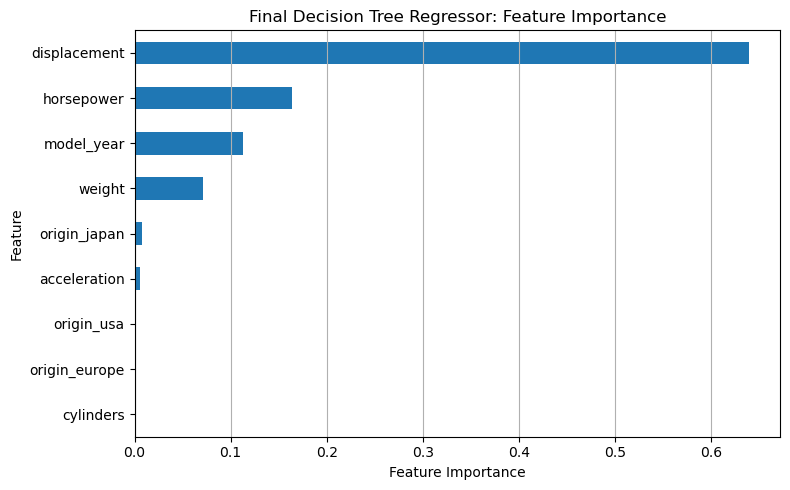

In [14]:
# --------------------------------------------------
# Feature Importance
# --------------------------------------------------

# Extract the fitted preprocessing step and decision tree
final_preprocessor = final_decision_tree_pipeline.named_steps[
    "columntransformer"
]

final_tree = final_decision_tree_pipeline.named_steps[
    "decisiontreeregressor"
]

# Retrieve the feature names created by preprocessing
feature_names = final_preprocessor.get_feature_names_out()

# Remove transformer prefixes such as
# "pipeline-1__" and "pipeline-2__"
feature_names = [
    feature_name.split("__")[-1]
    for feature_name in feature_names
]

# Create a Series of feature importances
feature_importance = pd.Series(
    final_tree.feature_importances_,
    index=feature_names
)

# Sort from largest to smallest
feature_importance = feature_importance.sort_values(
    ascending=False
)

# Plot
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Final Decision Tree Regressor: Feature Importance"
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.grid(axis="x")
plt.tight_layout()
plt.show()

#### Conclusions:

- The final decision tree relies most heavily on `displacement`, which accounts for the majority of the model’s total feature importance.

- `horsepower`, `model_year`, and `weight` make smaller but still meaningful contributions. The remaining predictors contribute relatively little to this particular fitted tree.

- This indicates that the tree’s fuel-economy predictions are driven primarily by engine size, with additional information provided by engine power, vehicle age, and weight.

## Decision Tree Classifier


### Load the dataset and do the test/train split

In [15]:
# --------------------------------------------------
# Load the Credit Card Default Dataset
# --------------------------------------------------

# UCI dataset ID 350:
# Default of Credit Card Clients
credit_data = fetch_ucirepo(id=350)

# Predictor variables
X_ccd = credit_data.data.features.copy()

# Rename predictors (these are more readable versions of the original names)
X_ccd.columns = [
    "credit_limit",
    "gender",
    "education",
    "marital_status",
    "age",
    "repay_status_sep",
    "repay_status_aug",
    "repay_status_jul",
    "repay_status_jun",
    "repay_status_may",
    "repay_status_apr",
    "bill_amt_sep",
    "bill_amt_aug",
    "bill_amt_jul",
    "bill_amt_jun",
    "bill_amt_may",
    "bill_amt_apr",
    "payment_amt_sep",
    "payment_amt_aug",
    "payment_amt_jul",
    "payment_amt_jun",
    "payment_amt_may",
    "payment_amt_apr"
]


# Binary target:
# 1 = defaulted the following month
# 0 = did not default
y_ccd = credit_data.data.targets.squeeze().copy()

# Give the target a simpler name
y_ccd.name = "default"

print("X shape:", X_ccd.shape)
print("y shape:", y_ccd.shape)

display(X_ccd.head())
display(y_ccd.value_counts())
print()
display(y_ccd.value_counts(normalize=True).round(4))

X shape: (30000, 23)
y shape: (30000,)


,credit_limit,gender,education,marital_status,age,repay_status_sep,repay_status_aug,repay_status_jul,repay_status_jun,repay_status_may,...,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,payment_amt_sep,payment_amt_aug,payment_amt_jul,payment_amt_jun,payment_amt_may,payment_amt_apr
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


default
0    23364
1     6636
Name: count, dtype: int64

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

### Decision Tree Classifier with Default Hyperparameters

We will first evaluate a decision tree classifier using its default hyperparameter values.

Because customers who default are the minority class, accuracy alone may not adequately describe model performance. A model could achieve relatively high accuracy by predicting that most customers will not default, while still failing to identify many customers who do default.

We will therefore use **ROC AUC** as the primary cross-validation metric. ROC AUC measures how well the model ranks customers who default above customers who do not default across all possible decision thresholds.

During final evaluation, we will also examine accuracy, F1 score, TPR, FPR, and the confusion matrix using the default decision threshold of 0.5.

In [16]:
# --------------------------------------------------
# Prepare the Predictors and Create the
# Development / Test Split
# --------------------------------------------------

# --------------------------------------------------
# Identify Predictor Types
# --------------------------------------------------

categorical_features = [
    "gender",
    "education",
    "marital_status"
]

quantitative_features = [
    feature
    for feature in X_ccd.columns
    if feature not in categorical_features
]


# --------------------------------------------------
# Development / Test Split
# --------------------------------------------------

X_ccd_development, X_ccd_test, y_ccd_development, y_ccd_test = train_test_split(
    X_ccd,
    y_ccd,
    test_size=0.10,
    stratify=y_ccd,
    random_state=random_seed
)

print("Development set:")
print(X_ccd_development.shape, y_ccd_development.shape)

print("\nTest set:")
print(X_ccd_test.shape, y_ccd_test.shape)

print("\nDevelopment target proportions:")
display(
    y_ccd_development
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("Test target proportions:")
display(
    y_ccd_test
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)


# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

# Impute quantitative predictors
quantitative_pipeline = make_pipeline(
    SimpleImputer(strategy="median")
)

# Impute and encode nominal categorical predictors
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),

    OneHotEncoder(
        handle_unknown="ignore"
    )
)

# Apply the appropriate preprocessing to each
# group of predictors
classification_preprocessor = make_column_transformer(
    (
        quantitative_pipeline,
        quantitative_features
    ),
    (
        categorical_pipeline,
        categorical_features
    )
)


# --------------------------------------------------
# Baseline Decision Tree Classification Pipeline
# --------------------------------------------------

decision_tree_classifier_pipeline = make_pipeline(
    classification_preprocessor,

    DecisionTreeClassifier(

        # Splitting criterion
        criterion="gini",

        # Tree size
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_leaf_nodes=None,

        # Feature selection
        max_features=None,

        # Cost-complexity pruning
        ccp_alpha=0.0,

        # Class weighting
        class_weight=None,

        # Reproducibility
        random_state=random_seed
    )
)


# --------------------------------------------------
# Stratified Five-Fold Cross-Validation
# --------------------------------------------------

classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)

cv_auc_scores = cross_val_score(
    decision_tree_classifier_pipeline,
    X_ccd_development,
    y_ccd_development,
    scoring="roc_auc",
    cv=classification_cv,
    n_jobs=-1
)


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("\nBaseline Decision Tree Classification")
print("-------------------------------------")
print(
    f"5-Fold AUCs : "
    f"{np.round(cv_auc_scores, 4)}"
)
print(
    f"Mean CV AUC : "
    f"{cv_auc_scores.mean():.4f}"
)
print(
    f"Std CV AUC  : "
    f"{cv_auc_scores.std():.4f}"
)

Development set:
(27000, 23) (27000,)

Test set:
(3000, 23) (3000,)

Development target proportions:


default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Test target proportions:


default
0    0.7787
1    0.2213
Name: proportion, dtype: float64


Baseline Decision Tree Classification
-------------------------------------
5-Fold AUCs : [0.6108 0.6172 0.6019 0.6121 0.6224]
Mean CV AUC : 0.6129
Std CV AUC  : 0.0069


### Hyperparameter Tuning: `max_depth`

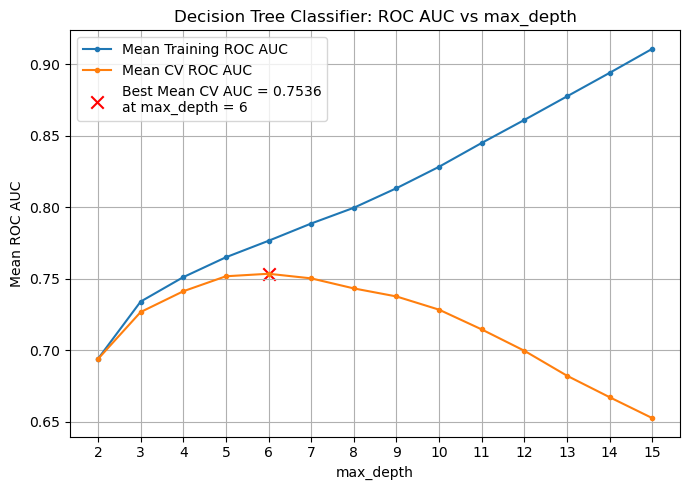

max_depth Tuning Results
------------------------
Best max_depth : 6
Mean CV AUC    : 0.7536
Std CV AUC     : 0.0095


In [17]:
# --------------------------------------------------
# Validation Curve for max_depth
# --------------------------------------------------

training_aucs = []
cv_aucs = []

training_auc_stds = []
cv_auc_stds = []

max_depth_values = range(2, 16)

for max_depth in max_depth_values:

    # Construct the full preprocessing + modeling pipeline
    max_depth_classifier_pipeline = make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            max_depth=max_depth,
            min_samples_split=2,
            min_samples_leaf=1,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=0.0,
            class_weight=None,
            random_state=random_seed
        )
    )

    # Evaluate training and validation ROC AUC
    # within each stratified cross-validation fold
    scores = cross_validate(
        max_depth_classifier_pipeline,
        X_ccd_development,
        y_ccd_development,
        scoring="roc_auc",
        cv=classification_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Store fold scores
    fold_training_aucs = scores["train_score"]
    fold_cv_aucs = scores["test_score"]

    # Store means
    training_aucs.append(
        fold_training_aucs.mean()
    )

    cv_aucs.append(
        fold_cv_aucs.mean()
    )

    # Store standard deviations
    training_auc_stds.append(
        fold_training_aucs.std()
    )

    cv_auc_stds.append(
        fold_cv_aucs.std()
    )


# --------------------------------------------------
# Identify the Best max_depth
# --------------------------------------------------

best_index = np.argmax(cv_aucs)

best_max_depth_classifier = list(
    max_depth_values
)[best_index]

best_max_depth_classifier_cv_auc = cv_aucs[
    best_index
]

best_max_depth_classifier_cv_auc_std = cv_auc_stds[
    best_index
]


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    max_depth_values,
    training_aucs,
    marker=".",
    label="Mean Training ROC AUC"
)

plt.plot(
    max_depth_values,
    cv_aucs,
    marker=".",
    label="Mean CV ROC AUC"
)

plt.scatter(
    best_max_depth_classifier,
    best_max_depth_classifier_cv_auc,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV AUC = "
        f"{best_max_depth_classifier_cv_auc:.4f}\n"
        f"at max_depth = "
        f"{best_max_depth_classifier}"
    )
)

plt.title(
    "Decision Tree Classifier: ROC AUC vs max_depth"
)
plt.xlabel("max_depth")
plt.ylabel("Mean ROC AUC")
plt.xticks(list(max_depth_values))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("max_depth Tuning Results")
print("------------------------")
print(
    f"Best max_depth : "
    f"{best_max_depth_classifier}"
)
print(
    f"Mean CV AUC    : "
    f"{best_max_depth_classifier_cv_auc:.4f}"
)
print(
    f"Std CV AUC     : "
    f"{best_max_depth_classifier_cv_auc_std:.4f}"
)

#### Conclusions:

- The training ROC AUC increases steadily as `max_depth` grows, showing that deeper trees fit the development folds more closely.

- The cross-validation ROC AUC initially improves as tree depth increases and reaches its maximum at `max_depth = 6`, with a mean CV AUC of **0.7536**. Beyond this point, training performance continues to improve while validation performance declines, providing clear evidence of overfitting.

- We therefore select `max_depth = 6` as the preferred value from this validation curve. It will later be compared with the models selected using the other hyperparameters through repeated cross-validation.

### Hyperparameter Tuning: `ccp_alpha`

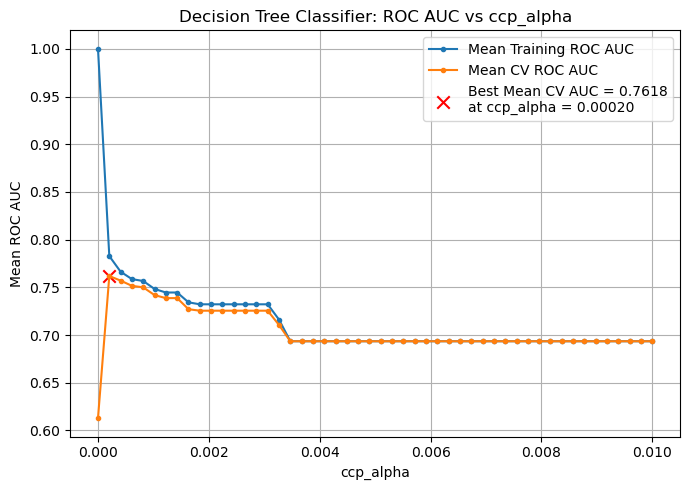

ccp_alpha Tuning Results
------------------------
Best ccp_alpha : 0.00020
Mean CV AUC    : 0.7618
Std CV AUC     : 0.0080


In [18]:
# --------------------------------------------------
# Validation Curve for ccp_alpha
# --------------------------------------------------

training_aucs = []
cv_aucs = []

training_auc_stds = []
cv_auc_stds = []

ccp_alpha_values = np.linspace(
    0.0,
    0.01,
    50
)

for ccp_alpha in ccp_alpha_values:

    # Construct the full preprocessing + modeling pipeline
    ccp_alpha_classifier_pipeline = make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=ccp_alpha,
            class_weight=None,
            random_state=random_seed
        )
    )

    # Evaluate training and validation ROC AUC
    # within each stratified cross-validation fold
    scores = cross_validate(
        ccp_alpha_classifier_pipeline,
        X_ccd_development,
        y_ccd_development,
        scoring="roc_auc",
        cv=classification_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Store fold scores
    fold_training_aucs = scores["train_score"]
    fold_cv_aucs = scores["test_score"]

    # Store means
    training_aucs.append(
        fold_training_aucs.mean()
    )

    cv_aucs.append(
        fold_cv_aucs.mean()
    )

    # Store standard deviations
    training_auc_stds.append(
        fold_training_aucs.std()
    )

    cv_auc_stds.append(
        fold_cv_aucs.std()
    )


# --------------------------------------------------
# Identify the Best ccp_alpha
# --------------------------------------------------

best_index = np.argmax(cv_aucs)

best_ccp_alpha_classifier = ccp_alpha_values[
    best_index
]

best_ccp_alpha_classifier_cv_auc = cv_aucs[
    best_index
]

best_ccp_alpha_classifier_cv_auc_std = cv_auc_stds[
    best_index
]


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    ccp_alpha_values,
    training_aucs,
    marker=".",
    label="Mean Training ROC AUC"
)

plt.plot(
    ccp_alpha_values,
    cv_aucs,
    marker=".",
    label="Mean CV ROC AUC"
)

plt.scatter(
    best_ccp_alpha_classifier,
    best_ccp_alpha_classifier_cv_auc,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV AUC = "
        f"{best_ccp_alpha_classifier_cv_auc:.4f}\n"
        f"at ccp_alpha = "
        f"{best_ccp_alpha_classifier:.5f}"
    )
)

plt.title(
    "Decision Tree Classifier: ROC AUC vs ccp_alpha"
)
plt.xlabel("ccp_alpha")
plt.ylabel("Mean ROC AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("ccp_alpha Tuning Results")
print("------------------------")
print(
    f"Best ccp_alpha : "
    f"{best_ccp_alpha_classifier:.5f}"
)
print(
    f"Mean CV AUC    : "
    f"{best_ccp_alpha_classifier_cv_auc:.4f}"
)
print(
    f"Std CV AUC     : "
    f"{best_ccp_alpha_classifier_cv_auc_std:.4f}"
)

#### Conclusions:

- The highest mean cross-validation ROC AUC occurs at `ccp_alpha = 0.00020`, with a mean CV AUC of **0.7618**.

- At `ccp_alpha = 0`, the tree fits the training folds almost perfectly but performs much worse on the validation folds, indicating severe overfitting. Introducing a small amount of cost-complexity pruning sharply reduces training performance while substantially improving validation performance.

- As `ccp_alpha` increases beyond the selected value, both training and validation ROC AUC generally decline. The tree becomes progressively simpler, but the additional pruning removes useful structure and leads to underfitting.

- We therefore select `ccp_alpha = 0.00020` as the preferred value from this validation curve. It will later be compared with the models selected using the other hyperparameters through repeated cross-validation.

### Hyperparameter Tuning: `min_samples_leaf`

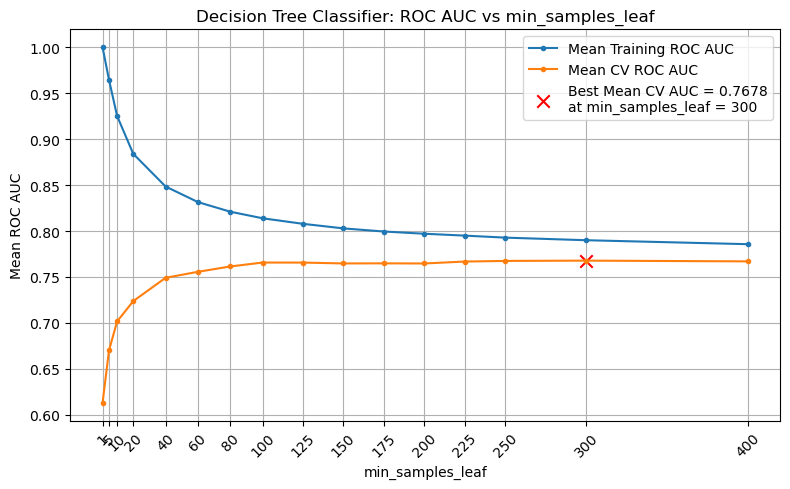

min_samples_leaf Tuning Results
--------------------------------
Best min_samples_leaf : 300
Mean CV AUC            : 0.7678
Std CV AUC             : 0.0060


In [19]:
# --------------------------------------------------
# Validation Curve for min_samples_leaf
# --------------------------------------------------

training_aucs = []
cv_aucs = []

training_auc_stds = []
cv_auc_stds = []

# Use a wider range because the exploratory grid search
# found that large minimum leaf sizes performed well
min_samples_leaf_values = [
    1, 5, 10, 20, 40, 60, 80,
    100, 125, 150, 175, 200,
    225, 250, 300, 400
]

for min_samples_leaf in min_samples_leaf_values:

    # Construct the full preprocessing + modeling pipeline
    min_samples_leaf_classifier_pipeline = make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=min_samples_leaf,
            max_leaf_nodes=None,
            max_features=None,
            ccp_alpha=0.0,
            class_weight=None,
            random_state=random_seed
        )
    )

    # Evaluate training and validation ROC AUC
    # within each stratified cross-validation fold
    scores = cross_validate(
        min_samples_leaf_classifier_pipeline,
        X_ccd_development,
        y_ccd_development,
        scoring="roc_auc",
        cv=classification_cv,
        return_train_score=True,
        n_jobs=-1
    )

    # Store fold scores
    fold_training_aucs = scores["train_score"]
    fold_cv_aucs = scores["test_score"]

    # Store means
    training_aucs.append(
        fold_training_aucs.mean()
    )

    cv_aucs.append(
        fold_cv_aucs.mean()
    )

    # Store standard deviations
    training_auc_stds.append(
        fold_training_aucs.std()
    )

    cv_auc_stds.append(
        fold_cv_aucs.std()
    )


# --------------------------------------------------
# Identify the Best min_samples_leaf
# --------------------------------------------------

best_index = np.argmax(cv_aucs)

best_min_samples_leaf_classifier = (
    min_samples_leaf_values[best_index]
)

best_min_samples_leaf_classifier_cv_auc = (
    cv_aucs[best_index]
)

best_min_samples_leaf_classifier_cv_auc_std = (
    cv_auc_stds[best_index]
)


# --------------------------------------------------
# Plot the Validation Curve
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    min_samples_leaf_values,
    training_aucs,
    marker=".",
    label="Mean Training ROC AUC"
)

plt.plot(
    min_samples_leaf_values,
    cv_aucs,
    marker=".",
    label="Mean CV ROC AUC"
)

plt.scatter(
    best_min_samples_leaf_classifier,
    best_min_samples_leaf_classifier_cv_auc,
    marker="x",
    color="red",
    s=80,
    label=(
        f"Best Mean CV AUC = "
        f"{best_min_samples_leaf_classifier_cv_auc:.4f}\n"
        f"at min_samples_leaf = "
        f"{best_min_samples_leaf_classifier}"
    )
)

plt.title(
    "Decision Tree Classifier: "
    "ROC AUC vs min_samples_leaf"
)
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean ROC AUC")
plt.xticks(
    min_samples_leaf_values,
    rotation=45
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Report the Best Result
# --------------------------------------------------

print("min_samples_leaf Tuning Results")
print("--------------------------------")
print(
    f"Best min_samples_leaf : "
    f"{best_min_samples_leaf_classifier}"
)
print(
    f"Mean CV AUC            : "
    f"{best_min_samples_leaf_classifier_cv_auc:.4f}"
)
print(
    f"Std CV AUC             : "
    f"{best_min_samples_leaf_classifier_cv_auc_std:.4f}"
)

#### Conclusions:

- The mean cross-validation ROC AUC improves sharply as `min_samples_leaf` increases from 1, showing that the default tree is substantially overfitting the development folds.

- Validation performance continues to improve more gradually as the minimum leaf size increases and reaches its highest value at `min_samples_leaf = 300`, with a mean CV AUC of **0.7678**.

- At the same time, the training ROC AUC steadily decreases and the gap between training and validation performance narrows. Requiring larger leaves prevents the tree from creating highly specific rules based on small groups of customers and produces a more stable model.

- The validation curve becomes relatively flat at larger values, so `min_samples_leaf = 300` should be treated as a promising candidate rather than as a uniquely optimal value. We will compare it with the other candidate models using repeated cross-validation.

### Comparing Candidate Tree Models

In [20]:
# --------------------------------------------------
# Compare Candidate Classifiers with Repeated CV
# --------------------------------------------------

# Repeated stratified 5-fold cross-validation
repeated_classification_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)


# --------------------------------------------------
# Candidate Modeling Pipelines
# --------------------------------------------------

candidate_classifiers = {

    "Default Tree": make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            random_state=random_seed
        )
    ),

    "Best max_depth": make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            max_depth=best_max_depth_classifier,
            random_state=random_seed
        )
    ),

    "Best ccp_alpha": make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            ccp_alpha=best_ccp_alpha_classifier,
            random_state=random_seed
        )
    ),

    "Best min_samples_leaf": make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            min_samples_leaf=best_min_samples_leaf_classifier,
            random_state=random_seed
        )
    ),

    "Combined Tree": make_pipeline(
        classification_preprocessor,

        DecisionTreeClassifier(
            criterion="gini",
            max_depth=best_max_depth_classifier,
            ccp_alpha=best_ccp_alpha_classifier,
            min_samples_leaf=best_min_samples_leaf_classifier,
            random_state=random_seed
        )
    )
}


# --------------------------------------------------
# Evaluate the Candidate Models
# --------------------------------------------------

candidate_classifier_results = []

for model_name, model_pipeline in candidate_classifiers.items():

    repeated_cv_auc_scores = cross_val_score(
        model_pipeline,
        X_ccd_development,
        y_ccd_development,
        scoring="roc_auc",
        cv=repeated_classification_cv,
        n_jobs=-1
    )

    candidate_classifier_results.append({
        "Candidate Model": model_name,
        "Mean Repeated-CV AUC": repeated_cv_auc_scores.mean(),
        "Std Repeated-CV AUC": repeated_cv_auc_scores.std()
    })


# --------------------------------------------------
# Create the Comparison Table
# --------------------------------------------------

candidate_classifier_results = pd.DataFrame(
    candidate_classifier_results
)

candidate_classifier_results = (
    candidate_classifier_results
    .sort_values(
        "Mean Repeated-CV AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

candidate_classifier_results.round(4)

/Users/waynesnyder/anaconda3/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/waynesnyder/anaconda3/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Candidate Model,Mean Repeated-CV AUC,Std Repeated-CV AUC
0,Best min_samples_leaf,0.7670,0.0052
1,Best ccp_alpha,0.7615,0.0060
2,Combined Tree,0.7598,0.0061
3,Best max_depth,0.7529,0.0076
4,Default Tree,0.6133,0.0072


#### Conclusions:

- The tree using `min_samples_leaf = 300` achieved the highest mean repeated cross-validation ROC AUC, at **0.7670**. It substantially outperformed the default tree, whose mean repeated-CV AUC was only **0.6133**.

- The tree selected using `ccp_alpha` performed next best, with a mean repeated-CV AUC of **0.7615**, while the combined tree achieved **0.7598**. This indicates that adding the selected `max_depth` and `ccp_alpha` restrictions did not improve on the simpler minimum-leaf-size model.

- The selected minimum-leaf-size model also performed consistently across the repeated folds, with a standard deviation of **0.0052**.

- We therefore select the tree with `min_samples_leaf = 300` as the final decision tree classifier.

### Final Test Evaluation

Repeated cross-validation identified the decision tree with `min_samples_leaf = 300` as the preferred classifier.

We will now refit this selected pipeline on the full development set and evaluate it once on the untouched test set.

ROC AUC will provide a threshold-independent measure of how well the model ranks customers who default above customers who do not default. We will then apply the default decision threshold of `0.5` and report accuracy, F1 score, TPR, FPR, and the confusion matrix.

In practice, the decision threshold could be adjusted to reflect the relative costs of false positives and false negatives, as discussed in Week 5. Here, however, we retain the default threshold so that this section remains focused on final model evaluation.

In [21]:
# --------------------------------------------------
# Final Decision Tree Classification Evaluation
# --------------------------------------------------

# --------------------------------------------------
# Retrieve the Selected Candidate
# --------------------------------------------------

final_classifier_pipeline = candidate_classifiers[
    "Best min_samples_leaf"
]

selected_tree_row = candidate_classifier_results.loc[
    candidate_classifier_results["Candidate Model"]
    == "Best min_samples_leaf"
].iloc[0]

tree_mean_cv_auc = selected_tree_row[
    "Mean Repeated-CV AUC"
]

tree_std_cv_auc = selected_tree_row[
    "Std Repeated-CV AUC"
]


# --------------------------------------------------
# Refit on the Full Development Set
# --------------------------------------------------

final_classifier_pipeline.fit(
    X_ccd_development,
    y_ccd_development
)


# --------------------------------------------------
# Generate Test-Set Predictions
# --------------------------------------------------

# Predicted probabilities for the default class
tree_test_prob = final_classifier_pipeline.predict_proba(
    X_ccd_test
)[:, 1]

# Apply the default decision threshold
decision_threshold = 0.50

tree_test_pred = (
    tree_test_prob >= decision_threshold
).astype(int)


# --------------------------------------------------
# Calculate Test Metrics
# --------------------------------------------------

tree_test_auc = roc_auc_score(
    y_ccd_test,
    tree_test_prob
)

tree_test_accuracy = accuracy_score(
    y_ccd_test,
    tree_test_pred
)

# Confusion matrix counts
tn, fp, fn, tp = confusion_matrix(
    y_ccd_test,
    tree_test_pred,
    labels=[0, 1]
).ravel()

# True Positive Rate and False Positive Rate
tree_test_tpr = tp / (tp + fn)
tree_test_fpr = fp / (fp + tn)

tree_test_f1 = f1_score(
    y_ccd_test,
    tree_test_pred
)


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Selected Decision Tree Classifier")
print("---------------------------------")
print(
    f"min_samples_leaf     : "
    f"{best_min_samples_leaf_classifier}"
)
print(
    f"Decision Threshold   : "
    f"{decision_threshold:.2f}"
)
print(
    f"Mean Repeated-CV AUC : "
    f"{tree_mean_cv_auc:.4f}"
)
print(
    f"Std Repeated-CV AUC  : "
    f"{tree_std_cv_auc:.4f}"
)
print(
    f"Test ROC AUC         : "
    f"{tree_test_auc:.4f}"
)
print(
    f"Test Accuracy        : "
    f"{tree_test_accuracy:.4f}"
)
print(
    f"Test F1 Score        : "
    f"{tree_test_f1:.4f}"
)
print(
    f"Test TPR             : "
    f"{tree_test_tpr:.4f}"
)
print(
    f"Test FPR             : "
    f"{tree_test_fpr:.4f}"
)


Selected Decision Tree Classifier
---------------------------------
min_samples_leaf     : 300
Decision Threshold   : 0.50
Mean Repeated-CV AUC : 0.7670
Std Repeated-CV AUC  : 0.0052
Test ROC AUC         : 0.7668
Test Accuracy        : 0.8237
Test F1 Score        : 0.4839
Test TPR             : 0.3735
Test FPR             : 0.0484


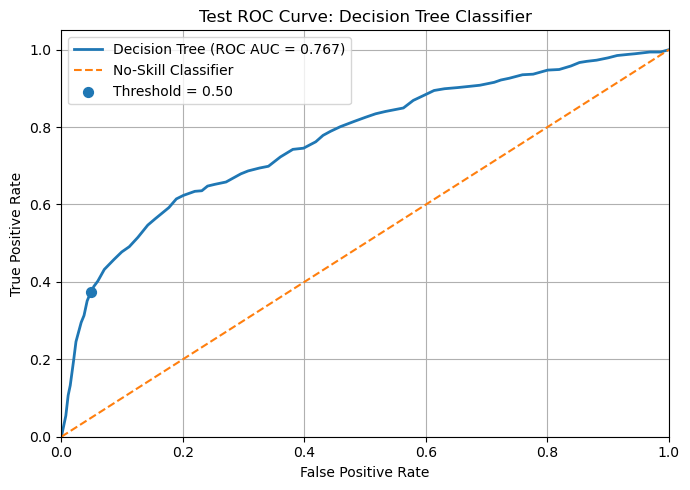

In [22]:
# --------------------------------------------------
# Test ROC Curve
# --------------------------------------------------

false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(
    y_ccd_test,
    tree_test_prob
)

plt.figure(figsize=(7, 5))

# ROC curve
plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"Decision Tree (ROC AUC = {tree_test_auc:.3f})"
)

# No-skill reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-Skill Classifier"
)

# Operating point produced by the default threshold
plt.scatter(
    tree_test_fpr,
    tree_test_tpr,
    marker="o",
    s=50,
    label=f"Threshold = {decision_threshold:.2f}"
)

plt.title("Test ROC Curve: Decision Tree Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Conclusions:

- The final decision tree achieved a test ROC AUC of 0.7668, indicating moderately strong discrimination across possible decision thresholds. 
- At the default threshold of 0.50, the model achieved a TPR of 0.3735 and an FPR of 0.0484. The marked point on the ROC curve shows this operating point.
- The test ROC AUC is almost identical to the mean repeated cross-validation AUC of 0.7670, suggesting that the cross-validation estimate generalized well to the untouched test set.
- As discussed in Week 5, lowering the threshold would generally increase TPR while also increasing FPR.

### Comparison with Logistic Regression Baseline

We will compare two approaches to predicting credit card default:

- a logistic regression model;
- the selected decision tree classifier.

Both models use the same predictors, development/test split, repeated stratified cross-validation folds, untouched test set, and decision threshold of `0.50`. Each model also includes its required preprocessing steps within the pipeline.

This provides a fair comparison of two different ways to represent relationships in the data:

- logistic regression models the log-odds of default as an additive linear combination of the predictors;
- a decision tree represents the data using a sequence of threshold-based regions and can capture nonlinear relationships and interactions automatically.

ROC AUC will be the primary metric because it evaluates how well each model ranks customers who default above those who do not across all possible decision thresholds. We will also compare accuracy,  F1 score, TPR, and FPR at the shared threshold of `0.50`.

In [23]:
# --------------------------------------------------
# Logistic Regression Baseline
# --------------------------------------------------

# --------------------------------------------------
# Logistic Regression Preprocessing
# --------------------------------------------------

# Impute and scale quantitative predictors
logistic_quantitative_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Impute and encode categorical predictors
logistic_categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(
        handle_unknown="ignore"
    )
)

# Apply the appropriate preprocessing to each
# group of predictors
logistic_preprocessor = make_column_transformer(
    (
        logistic_quantitative_pipeline,
        quantitative_features
    ),
    (
        logistic_categorical_pipeline,
        categorical_features
    )
)


# --------------------------------------------------
# Modeling Pipeline
# --------------------------------------------------

# All preprocessing is fitted separately within each
# cross-validation training fold
logistic_regression_pipeline = make_pipeline(
    logistic_preprocessor,

    LogisticRegression(
        max_iter=1000,
        random_state=random_seed
    )
)


# --------------------------------------------------
# Repeated Cross-Validation on the Development Set
# --------------------------------------------------

logistic_cv_auc_scores = cross_val_score(
    logistic_regression_pipeline,
    X_ccd_development,
    y_ccd_development,
    scoring="roc_auc",
    cv=repeated_classification_cv,
    n_jobs=-1
)

logistic_mean_cv_auc = logistic_cv_auc_scores.mean()
logistic_std_cv_auc = logistic_cv_auc_scores.std()


# --------------------------------------------------
# Final Test Evaluation
# --------------------------------------------------

logistic_regression_pipeline.fit(
    X_ccd_development,
    y_ccd_development
)

logistic_test_prob = (
    logistic_regression_pipeline.predict_proba(
        X_ccd_test
    )[:, 1]
)

decision_threshold = 0.50

logistic_test_pred = (
    logistic_test_prob >= decision_threshold
).astype(int)

logistic_test_auc = roc_auc_score(
    y_ccd_test,
    logistic_test_prob
)

logistic_test_accuracy = accuracy_score(
    y_ccd_test,
    logistic_test_pred
)

# Confusion matrix counts
tn, fp, fn, tp = confusion_matrix(
    y_ccd_test,
    logistic_test_pred,
    labels=[0, 1]
).ravel()

# True Positive Rate and False Positive Rate
logistic_test_tpr = tp / (tp + fn)
logistic_test_fpr = fp / (fp + tn)

logistic_test_f1 = f1_score(
    y_ccd_test,
    logistic_test_pred
)


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Logistic Regression Baseline")
print("----------------------------")
print(
    f"Decision Threshold   : "
    f"{decision_threshold:.2f}"
)
print(
    f"Mean Repeated-CV AUC : "
    f"{logistic_mean_cv_auc:.4f}"
)
print(
    f"Std Repeated-CV AUC  : "
    f"{logistic_std_cv_auc:.4f}"
)
print(
    f"Test ROC AUC         : "
    f"{logistic_test_auc:.4f}"
)
print(
    f"Test Accuracy        : "
    f"{logistic_test_accuracy:.4f}"
)
print(
    f"Test TPR             : "
    f"{logistic_test_tpr:.4f}"
)
print(
    f"Test FPR             : "
    f"{logistic_test_fpr:.4f}"
)
print(
    f"Test F1 Score        : "
    f"{logistic_test_f1:.4f}"
)

Logistic Regression Baseline
----------------------------
Decision Threshold   : 0.50
Mean Repeated-CV AUC : 0.7260
Std Repeated-CV AUC  : 0.0068
Test ROC AUC         : 0.7062
Test Accuracy        : 0.8113
Test TPR             : 0.2455
Test FPR             : 0.0278
Test F1 Score        : 0.3655


#### Conclusions:

| Model                  | Decision Threshold | Mean Repeated-CV AUC | Std Repeated-CV AUC | Test ROC AUC | Test Accuracy |   Test TPR |   Test FPR | Test F1 Score |
| ---------------------- | -----------------: | -------------------: | ------------------: | -----------: | ------------: | ---------: | ---------: | ------------: |
| Logistic Regression    |               0.50 |               0.7260 |              0.0068 |       0.7062 |        0.8113 |     0.2455 | **0.0278** |        0.3655 |
| Selected Decision Tree |               0.50 |           **0.7670** |          **0.0052** |   **0.7668** |    **0.8237** | **0.3735** |     0.0484 |    **0.4839** |

* The selected decision tree outperformed logistic regression on the primary model-selection metric. Its mean repeated cross-validation ROC AUC was **0.7670**, compared with **0.7260** for logistic regression.

* The same pattern appeared on the untouched test set. The decision tree achieved a test ROC AUC of **0.7668**, while logistic regression achieved **0.7062**. This suggests that the decision tree captured nonlinear relationships and interactions that logistic regression did not represent as effectively.

* Using the same default decision threshold of `0.50`, the decision tree also achieved higher accuracy, TPR, and F1 score. Its TPR was **0.3735**, compared with **0.2455** for logistic regression, so the tree identified a larger proportion of customers who actually defaulted.

* This higher TPR came with a higher False Positive Rate. The decision tree had an FPR of **0.0484**, compared with **0.0278** for logistic regression. Thus, at the default threshold, the tree identified more defaulters but also incorrectly flagged a larger proportion of customers who did not default.

* Overall, the decision tree was the stronger general classifier for this dataset because it achieved substantially higher ROC AUC in both repeated cross-validation and final test evaluation. The results at threshold `0.50` illustrate a separate operating-point tradeoff: the tree achieved a higher TPR at the cost of a somewhat higher FPR.

* In this notebook, the decision threshold is left at the default value of `0.50` because the focus is on **model selection using ROC AUC**, rather than on optimizing a business-specific operating point. As discussed in Week 5, a real application could subsequently tune the threshold to satisfy a requirement such as a minimum TPR while minimizing FPR.


## Notebook Conclusions

This notebook developed and evaluated decision tree models for both regression and classification.

* Decision trees do not require feature scaling, but missing values and categorical predictors must still be handled appropriately within the modeling pipeline.

* Repeated cross-validation provides a more stable basis for comparing promising candidate models than relying on a single validation split.

* Decision-tree hyperparameters often control overlapping aspects of model complexity. As a result, combining values selected independently for several hyperparameters does not necessarily improve performance.

* **For both datasets, `min_samples_leaf` provided the most effective control over tree complexity,** although the preferred values differed substantially between the regression and classification problems.

* On the Auto MPG dataset, quadratic regression slightly outperformed the selected decision tree, suggesting that smooth nonlinear relationships described this prediction problem particularly well.

* On the credit-default dataset, the selected decision tree outperformed logistic regression in both repeated cross-validation and test ROC AUC, suggesting that the tree captured nonlinear relationships and interactions that logistic regression represented less effectively.

* At the default decision threshold of `0.50`, the decision tree also achieved a higher True Positive Rate than logistic regression, but at the cost of a somewhat higher False Positive Rate. This illustrates that **model discrimination and decision-threshold behavior are related but distinct aspects of classification performance**.

* In this notebook, ROC AUC was used to select a strong general classifier without committing to a particular business operating point. As discussed in Week 5, the decision threshold could subsequently be tuned to achieve a business objective such as maintaining a required TPR while minimizing FPR.

The broader lesson is that no single model or hyperparameter setting is best for every dataset. Model selection should be guided by validation performance, the evaluation metric, interpretability requirements, and the goals of the application.


## Appendix: Important Decision Tree Hyperparameters

Decision trees can easily become too complex and overfit the training data. Several hyperparameters control tree growth, but they often regulate overlapping aspects of model complexity. Their preferred values therefore depend on the dataset and should usually be selected using cross-validation.

---

### `criterion`

The `criterion` parameter determines how the quality of a candidate split is measured.

For regression:

- `"squared_error"` minimizes squared error and predicts the mean within each leaf.
- `"absolute_error"` minimizes absolute error and predicts the median within each leaf.
- `"poisson"` is designed for nonnegative count-like targets.

For classification:

- `"gini"` uses Gini impurity.
- `"entropy"` and `"log_loss"` use information gain based on entropy.

**Best practices:**

- Use the default criterion as a reasonable starting point.
- Choose a criterion appropriate for the prediction task and target.
- Compare alternatives with cross-validation when there is a substantive reason to do so.
- `"absolute_error"` may be useful when robustness to extreme target values is important, but it can be considerably slower to fit.

---

### `max_depth`

`max_depth` limits the number of levels in the tree.

- A small value may produce an overly simple tree that underfits.
- A large value allows more complex relationships but may lead to overfitting.
- With `max_depth=None`, the tree continues growing until another stopping condition is reached.

**Best practices:**

- Examine both training and validation performance across a range of depths.
- Use a validation curve or cross-validation rather than relying on a universal recommended range.
- Prefer a shallower tree when its validation performance is comparable, because it is generally easier to interpret.

---

### `min_samples_split`

`min_samples_split` specifies the minimum number of training observations required to divide an internal node.

- Increasing it prevents the tree from splitting nodes that contain only a small number of observations.
- It can be specified as an integer count or as a fraction of the training data.

**Best practices:**

- Increase this value when the tree creates highly specific branches based on small groups of observations.
- For datasets of very different sizes, a fractional value may be easier to interpret consistently.
- Evaluate it with cross-validation because its effect overlaps with `min_samples_leaf`.

---

### `min_samples_leaf`

`min_samples_leaf` specifies the minimum number of training observations allowed in each terminal leaf.

- Small values allow highly specific predictions and may lead to overfitting.
- Larger values produce broader, smoother, and generally more stable predictions.
- It may be specified as an integer count or as a fraction of the training data.

**Best practices:**

- This is often one of the most effective hyperparameters for controlling overfitting.
- Examine a sufficiently wide range; the preferred value may be much larger than the default.
- Use cross-validation to balance model flexibility against stability.

---

### `max_leaf_nodes`

`max_leaf_nodes` limits the total number of terminal leaves. When specified, the tree grows in a best-first manner, adding the splits that provide the greatest impurity reduction.

**Best practices:**

- Use this parameter when the total number of decision regions is easier to interpret than tree depth.
- Smaller values produce simpler and more interpretable trees.
- Select the value using cross-validation rather than relying on a fixed range.

---

### `splitter`

`splitter` controls how candidate splits are selected at each node.

- `"best"` chooses the strongest available split.
- `"random"` selects among randomly generated candidate splits.

**Best practices:**

- Use `"best"` for a standard single decision tree.
- `"random"` introduces additional randomness and may be useful for experimentation, but it does not guarantee faster or better performance.
- Randomized splitting is more commonly exploited as part of ensemble methods.

---

### `max_features`

`max_features` controls how many predictors are considered when searching for a split.

- `None` considers all predictors.
- An integer specifies an exact number.
- A float specifies a fraction.
- `"sqrt"` and `"log2"` use functions of the total number of predictors.

**Best practices:**

- For a single interpretable decision tree, `None` is usually a sensible starting point.
- Restricting the number of predictors introduces randomness and may reduce correlation among trees in ensemble methods.
- Consider tuning this parameter primarily when the dataset has many predictors or when building random forests and related ensembles.

---

### `ccp_alpha`

`ccp_alpha` controls minimal cost-complexity pruning.

- `ccp_alpha = 0` applies no cost-complexity pruning.
- Larger values remove branches whose improvement is too small relative to the complexity they add.
- Values that are too large may remove useful structure and cause underfitting.

**Best practices:**

- Begin with values close to zero and examine both training and validation performance.
- Use cross-validation to select the amount of pruning.
- The `cost_complexity_pruning_path` method can provide candidate values of `ccp_alpha`.
- Remember that pruning may overlap with restrictions such as `max_depth` and `min_samples_leaf`; combining their individually preferred values does not necessarily produce the best model.

---

### General Guidance

- Begin with a baseline tree using default hyperparameters.
- Tune one parameter at a time with validation curves to understand how each affects underfitting and overfitting.
- Compare promising candidate models with repeated cross-validation when a more stable comparison is needed.
- Do not assume that combining individually selected hyperparameter values will improve performance.
- Reserve the test set for one final evaluation after model selection is complete.